In [2]:
pip install tensorflow

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/332.0 MB 2.4 MB/s eta 0:02:20
   ---------------------------------------- 1.3/332.0 MB 2.5 MB/s eta 0:02:13
   ---------------------------------------- 1.8/332.0 MB 2.9 MB/s eta 0:01:55
   ---------------------------------------- 2.6/332.0 MB 3.1 MB/s eta 0:01:46
   ---------------------------------------- 3.7/332.0 MB 3.3 MB/s eta 0:01:40
    --------------------------------------- 4.5/332.0 MB 3.4 MB/s eta 0:01:37
    --------------------------------------- 5.5/332.0 MB 3.7 MB/s eta 0:01:30
    --------------------------------------- 6.8/332.0 MB 3.9 MB/s eta 0:01:24
    --------------------------------------- 8.1/332.0 MB 4.2 MB/s eta 0:01:18
   - -------------------------------------- 9.2/332.0 MB 4.4 MB/s eta 0:01:14
   - --

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os
import time

In [15]:
base_dir = os.path.join(os.path.dirname("C:\\Users\\alias\\Downloads\\cats_and_dogs_filtered"), "cats_and_dogs_filtered")
TRAIN_DIR = os.path.join(base_dir, 'train')
VAL_DIR   = os.path.join(base_dir, 'validation')


In [16]:
IMG_HEIGHT = 150
IMG_WIDTH  = 150
BATCH_SIZE = 32
EPOCHS     = 15

In [17]:
train_gen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_gen = keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)


Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [18]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


c:\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
start_time = time.time()

history = model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data
)

end_time = time.time()
print("Training time (minutes):", (end_time - start_time) / 60)


Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 43s 652ms/step - accuracy: 0.4925 - loss: 0.7141 - val_accuracy: 0.5030 - val_loss: 0.6930
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 334ms/step - accuracy: 0.4865 - loss: 0.6940 - val_accuracy: 0.4980 - val_loss: 0.6926
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 322ms/step - accuracy: 0.5395 - loss: 0.6889 - val_accuracy: 0.5630 - val_loss: 0.6821
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 324ms/step - accuracy: 0.5470 - loss: 0.6825 - val_accuracy: 0.6180 - val_loss: 0.6616
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 332ms/step - accuracy: 0.5890 - loss: 0.6766 - val_accuracy: 0.5720 - val_loss: 0.6737
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 319ms/step - accuracy: 0.5550 - loss: 0.6812 - val_accuracy: 0.6170 - val_loss: 0.6553
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 312ms/step - accuracy: 0.6080 - loss: 0.6610 - val_accuracy: 0.6510 - val_loss: 0.6499
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 312ms/step - accuracy: 0.6455 - loss: 0.6394 - val_accu

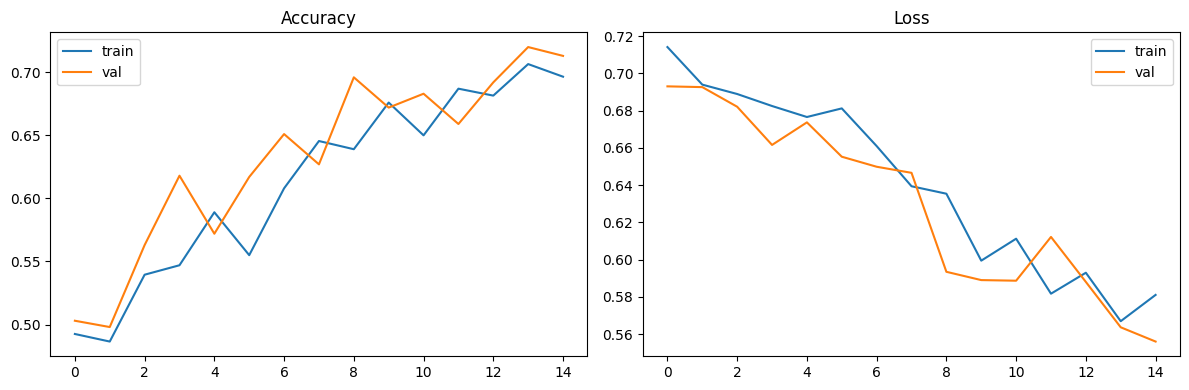

In [22]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Experiment A

In [23]:
def build_model_A():
    model = keras.Sequential([
        layers.Conv2D(8, (3,3), activation='relu',
                      input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(16, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model_A = build_model_A()

model_A.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_A.summary()

history_A = model_A.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data
)


c:\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9248)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,183,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,190,033 (4.54 MB)

 Trainable params: 1,190,033 (4.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 463ms/step - accuracy: 0.5300 - loss: 0.6889 - val_accuracy: 0.6120 - val_loss: 0.6736
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.5835 - loss: 0.6655 - val_accuracy: 0.5270 - val_loss: 0.7309
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.6040 - loss: 0.6514 - val_accuracy: 0.6150 - val_loss: 0.6320
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.6425 - loss: 0.6282 - val_accuracy: 0.6690 - val_loss: 0.5880
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.6705 - loss: 0.6060 - val_accuracy: 0.7030 - val_loss: 0.5746
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.6835 - loss: 0.5765 - val_accuracy: 0.6140 - val_loss: 0.7229
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.6925 - loss: 0.5834 - val_accuracy: 0.7110 - val_loss: 0.5547
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.6970 - loss: 0.5649 - val_accuracy: 

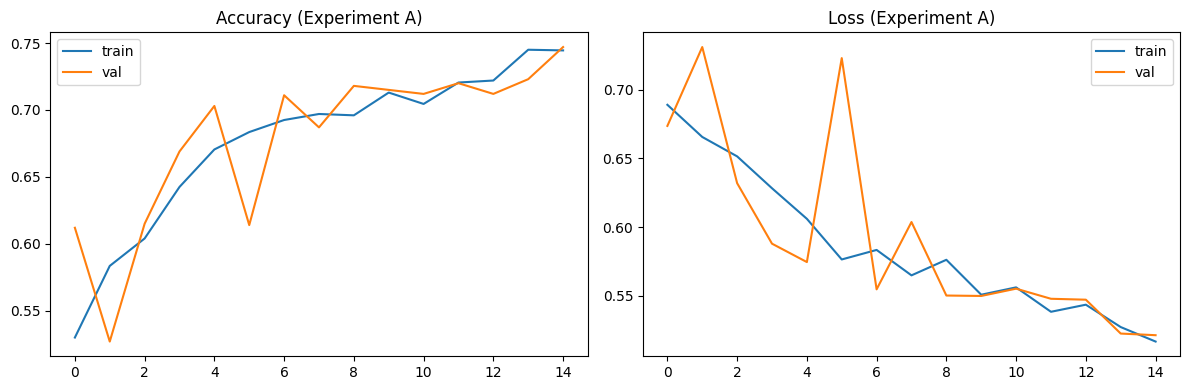

In [24]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_A.history['accuracy'], label='train')
plt.plot(history_A.history['val_accuracy'], label='val')
plt.title('Accuracy (Experiment A)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_A.history['loss'], label='train')
plt.plot(history_A.history['val_loss'], label='val')
plt.title('Loss (Experiment A)')
plt.legend()

plt.tight_layout()
plt.show()

Experiment B

In [25]:
def build_model_B():
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), strides=2, activation='relu',
                      input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        layers.Conv2D(64, (3,3), strides=2, activation='relu'),

        layers.Conv2D(128, (3,3), strides=2, activation='relu'),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model_B = build_model_B()

model_B.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_B.summary()

history_B = model_B.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data
)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 74, 74, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 36, 36, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 17, 17, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 213ms/step - accuracy: 0.5340 - loss: 0.6994 - val_accuracy: 0.5660 - val_loss: 0.6862
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 197ms/step - accuracy: 0.5635 - loss: 0.6847 - val_accuracy: 0.5920 - val_loss: 0.6755
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 192ms/step - accuracy: 0.5970 - loss: 0.6703 - val_accuracy: 0.5870 - val_loss: 0.6696
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 188ms/step - accuracy: 0.6140 - loss: 0.6565 - val_accuracy: 0.6080 - val_loss: 0.6630
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - accuracy: 0.6155 - loss: 0.6603 - val_accuracy: 0.6080 - val_loss: 0.6609
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step - accuracy: 0.6310 - loss: 0.6422 - val_accuracy: 0.6760 - val_loss: 0.6177
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - accuracy: 0.6550 - loss: 0.6198 - val_accuracy: 0.6560 - val_loss: 0.6185
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - accuracy: 0.6585 - loss: 0.6256 - val_accu

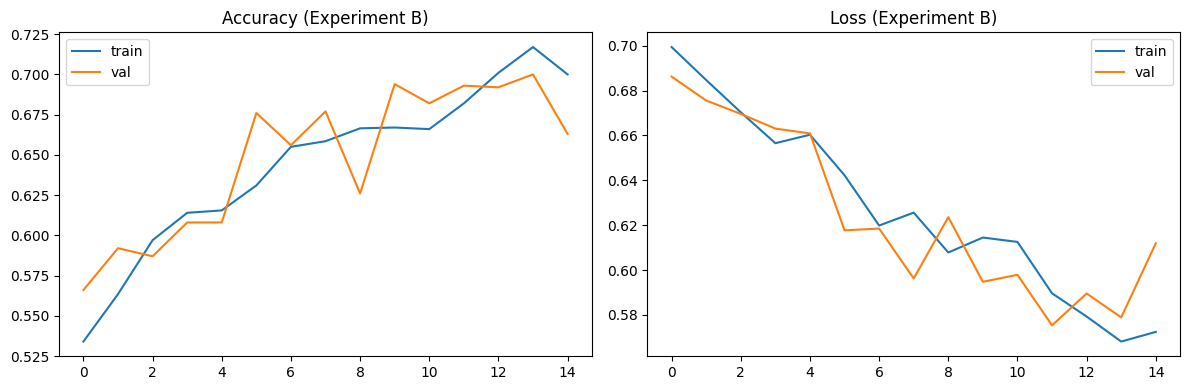

In [26]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_B.history['accuracy'], label='train')
plt.plot(history_B.history['val_accuracy'], label='val')
plt.title('Accuracy (Experiment B)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_B.history['loss'], label='train')
plt.plot(history_B.history['val_loss'], label='val')
plt.title('Loss (Experiment B)')
plt.legend()

plt.tight_layout()
plt.show()

Experiment C

In [28]:
def build_model_C():
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu',
                      input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model_C = build_model_C()

model_C.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_C.summary()

history_C = model_C.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data
)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 346ms/step - accuracy: 0.5580 - loss: 0.7039 - val_accuracy: 0.5760 - val_loss: 0.6776
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 321ms/step - accuracy: 0.5610 - loss: 0.6785 - val_accuracy: 0.6070 - val_loss: 0.6322
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 317ms/step - accuracy: 0.6185 - loss: 0.6515 - val_accuracy: 0.6510 - val_loss: 0.6264
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step - accuracy: 0.6490 - loss: 0.6124 - val_accuracy: 0.6930 - val_loss: 0.5915
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step - accuracy: 0.7040 - loss: 0.5648 - val_accuracy: 0.6880 - val_loss: 0.5897
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 318ms/step - accuracy: 0.7045 - loss: 0.5712 - val_accuracy: 0.6870 - val_loss: 0.5678
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 324ms/step - accuracy: 0.7245 - loss: 0.5556 - val_accuracy: 0.6860 - val_loss: 0.5725
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 322ms/step - accuracy: 0.7285 - loss: 0.5325 - val_accu

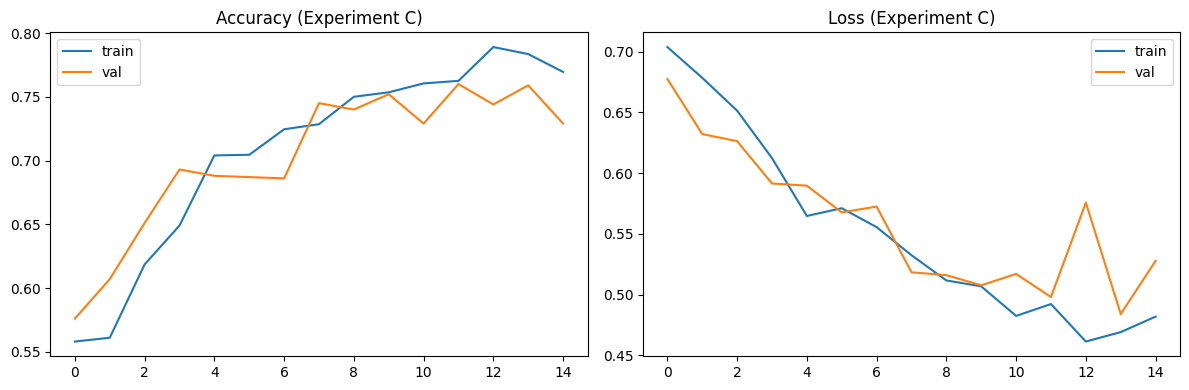

In [31]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_C.history['accuracy'], label='train')
plt.plot(history_C.history['val_accuracy'], label='val')
plt.title('Accuracy (Experiment C)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_C.history['loss'], label='train')
plt.plot(history_C.history['val_loss'], label='val')
plt.title('Loss (Experiment C)')
plt.legend()

plt.tight_layout()
plt.show()

Experiment D

In [33]:
def build_model_D():
    return keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu',
                      input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

model_D = build_model_D()

model_D.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_D.summary()

history_D = model_D.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data
)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 38s 592ms/step - accuracy: 0.4895 - loss: 0.6946 - val_accuracy: 0.5000 - val_loss: 0.6910
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 284ms/step - accuracy: 0.5170 - loss: 0.6918 - val_accuracy: 0.5350 - val_loss: 0.6873
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 290ms/step - accuracy: 0.5280 - loss: 0.6903 - val_accuracy: 0.5130 - val_loss: 0.6891
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 289ms/step - accuracy: 0.5430 - loss: 0.6885 - val_accuracy: 0.5060 - val_loss: 0.6859
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 288ms/step - accuracy: 0.5385 - loss: 0.6878 - val_accuracy: 0.6020 - val_loss: 0.6807
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 287ms/step - accuracy: 0.5465 - loss: 0.6858 - val_accuracy: 0.6050 - val_loss: 0.6789
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 288ms/step - accuracy: 0.5650 - loss: 0.6836 - val_accuracy: 0.5930 - val_loss: 0.6738
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 287ms/step - accuracy: 0.5650 - loss: 0.6812 - val_accu

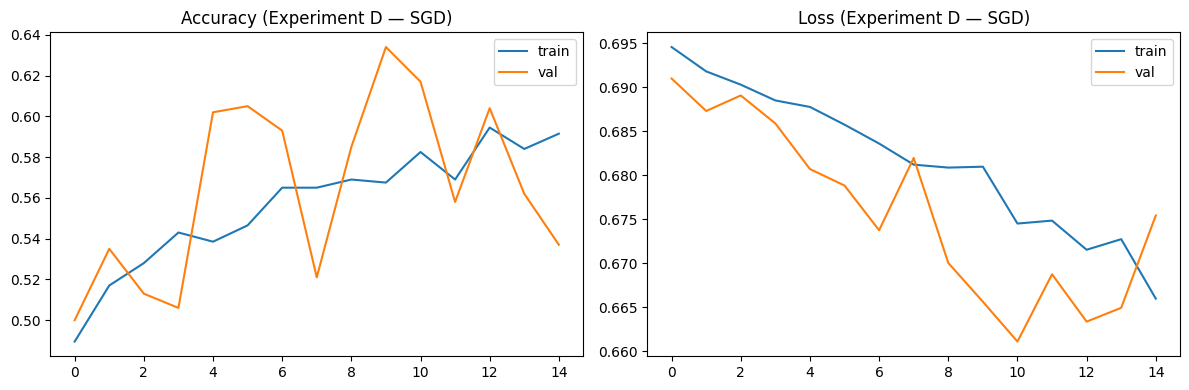

In [34]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_D.history['accuracy'], label='train')
plt.plot(history_D.history['val_accuracy'], label='val')
plt.title('Accuracy (Experiment D — SGD)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_D.history['loss'], label='train')
plt.plot(history_D.history['val_loss'], label='val')
plt.title('Loss (Experiment D — SGD)')
plt.legend()

plt.tight_layout()
plt.show()

Experiment E

In [35]:
def build_model_E():
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu',
                      input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(256, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model


model_E = build_model_E()

model_E.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_E.summary()

history_E = model_E.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data
)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,600,193 (13.73 MB)

 Trainable params: 3,600,193 (13.73 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 354ms/step - accuracy: 0.5075 - loss: 0.6967 - val_accuracy: 0.5470 - val_loss: 0.6923
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 321ms/step - accuracy: 0.5020 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 318ms/step - accuracy: 0.4935 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6875
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 319ms/step - accuracy: 0.5090 - loss: 0.6919 - val_accuracy: 0.5000 - val_loss: 0.6939
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 316ms/step - accuracy: 0.4940 - loss: 0.6946 - val_accuracy: 0.4980 - val_loss: 0.6921
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 319ms/step - accuracy: 0.5345 - loss: 0.6889 - val_accuracy: 0.5300 - val_loss: 0.6855
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 322ms/step - accuracy: 0.5425 - loss: 0.6878 - val_accuracy: 0.4990 - val_loss: 0.6953
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 316ms/step - accuracy: 0.5460 - loss: 0.6847 - val_accu

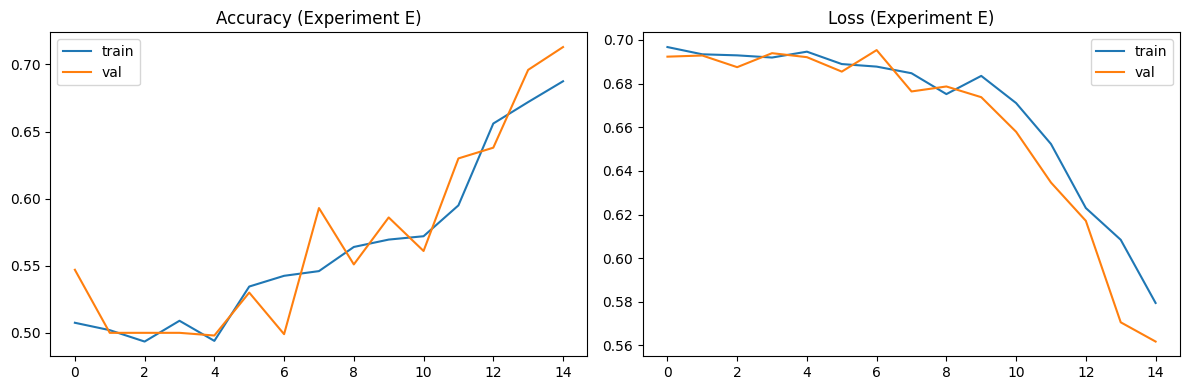

In [36]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_E.history['accuracy'], label='train')
plt.plot(history_E.history['val_accuracy'], label='val')
plt.title('Accuracy (Experiment E)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_E.history['loss'], label='train')
plt.plot(history_E.history['val_loss'], label='val')
plt.title('Loss (Experiment E)')
plt.legend()

plt.tight_layout()
plt.show()